In [ ]:
import czifile
import os
import numpy as np
from skimage.morphology import remove_small_objects
from skimage.measure import label, regionprops
from scipy.ndimage import binary_fill_holes
import matplotlib.pyplot as plt
from skimage import io
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

def remove_large_objects(arr, max_size):
    # Invert mask to treat large objects as small holes
    inv = ~arr
    cleaned = ~remove_small_objects(inv, min_size=max_size)
    return cleaned

In [ ]:
base_dir = '/home/michielvc/mountfs3/2025/Christian Zwicker_UCSc/2025_09_24_ChristianZ_Axioscan/'
im_files = os.listdir(base_dir)
wdir = '/srv/data/michielvc/data/other_projects/christian/final_data/segments/'
file_names = list(f.split('__')[1][:-4] for f in im_files)

# define intensity thresholds for macrophage segmentation based on assessment in QuPath
t2 = 3472
t3 = 2100

### Segment tissue and veins from manual thresholding and cleanign

In [ ]:
# go over all files individually
i = 5
im_file, file_name  = im_files[i], file_names[i]
im_data = czifile.imread(base_dir + im_file).squeeze()

In [ ]:
# go over all scenes individually
scene_oi = 0
print(f'file {file_name}  scene {scene_oi}')
im_data2 = im_data[scene_oi]
mask = im_data2.sum(axis=0) > 0
cut_bbox = regionprops(label(mask))[0].bbox
image_cut = im_data2[:, cut_bbox[0]:cut_bbox[2], cut_bbox[1]:cut_bbox[3]]

file 24877  scene 0


(-0.5, 3246.5, 2794.5, -0.5)

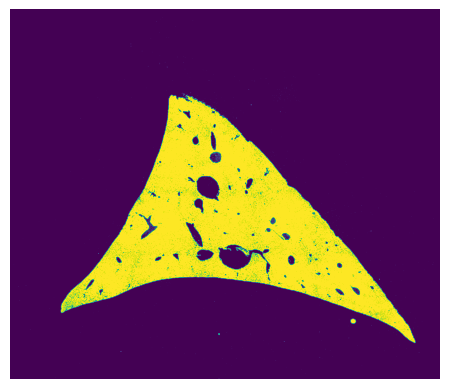

In [ ]:
# Segment tissue based on DAPI channel
dapi = image_cut[0]
tissue_and_holes = dapi > 220
# whole tissue is obtained by filling holes in tissue_and_holes and removing small objects as cleaning step
tissue = remove_small_objects(binary_fill_holes(tissue_and_holes), min_size=10000000)
plt.imshow(tissue_and_holes[::4,::4])
plt.axis('off')

In [ ]:
# holes are logical XOR of tissue and tissue_and_holes
raw_veins = tissue * ~tissue_and_holes
# veins are then the larger holes (assessed visually)
veins = binary_fill_holes(remove_small_objects(raw_veins, min_size=600))

plt.figure(figsize=(30,30))
plt.imshow(veins[::4,::4])
plt.axis('off')

In [ ]:
# save veins and tissue segmentations
io.imsave(os.path.join(wdir, f'veins/{file_name}_scene{scene_oi}.png'), veins)
io.imsave(os.path.join(wdir, f'tissue/{file_name}_scene{scene_oi}.png'), tissue)

/tmp/ipykernel_3967463/2268793800.py:1: UserWarning: /srv/data/michielvc/data/other_projects/christian/final_data/segments/veins/24877_scene0.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  io.imsave(os.path.join(wdir, f'veins/{file_name}_scene{scene_oi}.png'), veins)
/tmp/ipykernel_3967463/2268793800.py:2: UserWarning: /srv/data/michielvc/data/other_projects/christian/final_data/segments/tissue/24877_scene0.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  io.imsave(os.path.join(wdir, f'tissue/{file_name}_scene{scene_oi}.png'), tissue)
/tmp/ipykernel_3967463/2268793800.py:2: UserWarning: /srv/data/michielvc/data/other_projects/christian/final_data/segments/tissue/24877_scene0.png is a boolean image: setting True to 255 and False to 0. To silence this warning, please convert the image using img_as_ubyte.
  io.imsave(os.pat

### Segment Glul Sigal by intensity thresholding and cleaning

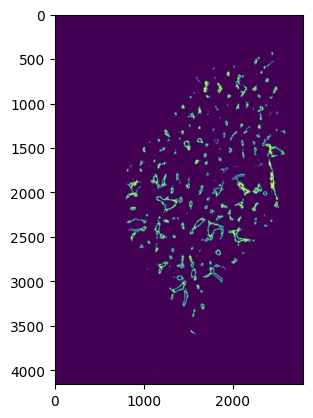

In [ ]:
glul = image_cut[1]
glul_segments = glul > 5000
plt.imshow(glul_segments[::4,::4])
io.imsave(os.path.join(wdir, f'glul/{file_name}_scene{scene_oi}.png'), glul_segments)

### Segment kcs

In [ ]:
clec4f = image_cut[2]
kc_segs1 = clec4f > t2
kc_segs1 = remove_small_objects(kc_segs1, min_size=150)
kc_segs1 = kc_segs1 ^ remove_small_objects(kc_segs1, min_size=3000)
io.imsave(os.path.join(wdir, f'kcs/vsig4/{file_name}_scene{scene_oi}.png'), kc_segs1.astype(np.uint8)*255)

f480 = image_cut[3]
kc_segs2 = f480 > t3
kc_segs2 = remove_small_objects(kc_segs2, min_size=150)
kc_segs2 = kc_segs2 ^ remove_small_objects(kc_segs2, min_size=3000)
io.imsave(os.path.join(wdir, f'kcs/f480/{file_name}_scene{scene_oi}.png'), kc_segs1.astype(np.uint8)*255)
